In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import odr

# Lab Portion


## Calibration


In [216]:
centroids = np.array([680.33, 769.49, 215.34, 392.4])
centroid_fwhm = np.array([29.9564, 31.1873, 16.8211, 28.4043])
energies = np.array(
    [
        1173.2,
        1332.5,
        356.0,
        661.6,
    ]
)

In [217]:
df = pd.DataFrame(
    {
        "Centroids": centroids[: len(energies)],
        "Energies": energies,
    }
)

df["Centroid_unc"] = centroid_fwhm / 2
df["Energy_unc"] = 0  # For the purposes of ODR
df

,Centroids,Energies,Centroid_unc,Energy_unc
0,680.33,1173.2,14.97820,0
1,769.49,1332.5,15.59365,0
2,215.34,356.0,8.41055,0
3,392.40,661.6,14.20215,0


In [218]:
data = odr.RealData(
    df["Centroids"],
    df["Energies"],
    sx=df["Centroid_unc"],
)


def regres_model(p, x):
    return p[0] * x + p[1]


model = odr.Model(regres_model)
odr_fit = odr.ODR(data, model, beta0=[1, 0])
out = odr_fit.run()

slope = out.beta[0]
intercept = out.beta[1]
slope_std_err = out.sd_beta[0]
intercept_std_err = out.sd_beta[1]
# print("Errors:", slope_std_err, intercept_std_err)

In [219]:
def channel_to_energy(channel):
    return slope * channel + intercept


def channel_to_energy_unc(channel, channel_unc):
    """
    Obtains uncertainties associated with an energy
    found using the linear regression model.
    """

    # Propagate uncertainties through product
    m_x = slope * channel
    m_perc = slope_std_err / slope
    channel_perc = channel_unc / channel
    m_x_unc = m_x * np.sqrt(m_perc**2 + channel_perc**2)

    # Propagate uncertainties through sum
    outer_err = np.sqrt(m_x_unc**2 + intercept_std_err**2)

    return outer_err

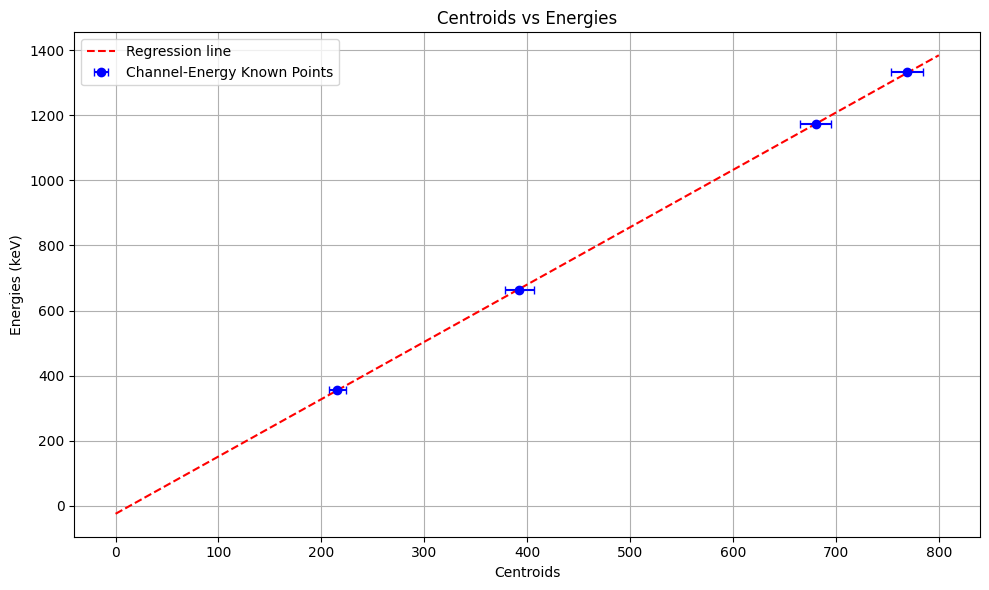

In [245]:
plt.figure(figsize=(10, 6))
# plt.scatter(
#     df["Centroids"],
#     df["Energies"],
#     color="blue",
#     marker="o",
#     label="Channel-Energy Known Points",
# )
plt.errorbar(
    df["Centroids"],
    df["Energies"],
    color="blue",
    fmt="o",
    label="Channel-Energy Known Points",
    xerr=df["Centroid_unc"],
    capsize=3
)
plt.xlabel("Centroids")
plt.ylabel("Energies (keV)")
plt.title("Centroids vs Energies")
plt.grid(True)

c_linspace = np.linspace(0, 800)
e_linspace = channel_to_energy(c_linspace)

line = slope * df["Centroids"] + intercept
plt.plot(
    c_linspace,
    e_linspace,
    color="red",
    linestyle="--",
    label="Regression line",
)
plt.legend()

plt.tight_layout()
plt.show()

## Unknown-Sample Data


In [221]:
unknown_centroids = np.array([135.37, 349.16, 488.61])
unknown_fwhm = np.array([29.2727, 2.5797, 28.4532])

# Analysis


## Question 1


In [222]:
step3 = np.array([149, 118, 137, 128, 128, 135, 112, 133, 133, 121])

In [223]:
sample_std = step3.std(ddof=1)
step3_mean = step3.mean()
theor_std = np.sqrt(step3_mean)
print(sample_std / theor_std)

0.9296017254842825


The ratio of the sample standard deviation to the theorical standard deviation (square root of the sample mean) is about 0.93, well within the 0.85 to 1.15 range. This provides evidence that the data is reasonably close to following a Gaussian distribution.


## Question 2


In [224]:
step3_sdom = sample_std / np.sqrt(len(step3))
step3_time = 20
step3_time_unc = 0.01
step3_rate = step3_mean / step3_time
sdom_perc = step3_sdom / step3_mean
time_perc = step3_time_unc / step3_time
step3_rate_unc = step3_rate * np.sqrt(sdom_perc**2 + time_perc**2)
print(step3_rate, step3_rate_unc)

6.470000000000001 0.16723044214662458


Using the data from step 3, the channel-400 peak's count rate is $(6.47 \pm 0.17)$ counts per second.


## Question 3


In [225]:
channel_to_energy(unknown_centroids)

array([214.00420105, 590.3972175 , 835.90919721])

In [226]:
channel_to_energy_unc(unknown_centroids, unknown_fwhm / 2)

array([26.02420863,  4.93065895, 25.55707506])

The energies corresponding to the three peaks found are:

- 210 $\pm$ 30 keV
- 590 $\pm$ 5 keV
- 840 $\pm$ 30 keV


## Question 4

Mn-54.


## Question 5


The absolute shortest half life I would expect would be on the order of a month or two months; these elements do not remain radioactive for long enough to be of use in our labs. The absolute largest half life I would expect is on the order of thousands of years; past this point, it seems unlikely that the element is radioactive enough to be considered interesting for analysis.

Mn-54 is the most likely candidate for this unknown element. Although two lower-energy peaks were included in the energies above, these two peaks were not nearly as prominent as the 835-keV peak in the spectrum collected from the sample; I focused on this peak. The reference table provided includes a data point for Mn-54 with an energy of 834.8, well within 1 $\sigma$ of my energy measurement. Further, there are no other energies listed for Mn-54 in the reference table, in agreement with the single peak observed on the spectrum. The half-life listed for Mn-54 is 312.2 days, which aligns with the expectation of a half life on the order of a few years.


# Written Portion


## Question 3


In [227]:
meas = np.array([1.59, 1.64, 1.63, 1.52, 1.69, 1.58]) * 1e-19

In [228]:
meas.mean()

np.float64(1.6083333333333334e-19)

In [229]:
sdom = meas.std(ddof=1) / np.sqrt(len(meas))
sdom

np.float64(2.386303510546059e-21)

In [230]:
sdom * 1e3

np.float64(2.386303510546059e-18)

In [231]:
masses = np.array(
    [
        9.25,
        9.17,
        9.22,
        9.10,
        9.19,
        9.05,
    ]
)

In [232]:
masses.mean()

np.float64(9.163333333333334)

In [233]:
masses.std() / np.sqrt(len(masses))

np.float64(0.028054180384339072)

In [234]:
# def unc_e_sq(e, unc_e):
#     return 2 * e * unc_e
#
#
# def unc_m_cu(m, unc_m):
#     return 3 * (m**2) * unc_m


def dBde(e, m):
    return 4 * e / m**3


def dBdm(e, m):
    return -6 * e**3 / m**4


def unc_total(e, m, unc_e, unc_m):
    t1 = dBde(e, m) * unc_e
    t2 = dBdm(e, m) * unc_m
    return np.sqrt(t1**2 + t2**2)

In [235]:
unc_total(1.61e-19, 9.16e-31, 0.02e-19, 0.03e-31)

np.float64(1.675827998510116e+51)

In [236]:
e = 1.61e-19
m = 9.16e-31
2 * (e**2 / m**3)

6.745207694003217e+52

## Question 4


In [237]:
plates = np.array([5.16, 4.47, 5.26, 4.50, 5.18, 5.12])
plates_unc = np.array([0.01] * 6)

thickness = [plates[: i + 1].sum() for i in range(len(plates))]
thickness_unc = [plates_unc[: i + 1].sum() for i in range(len(plates))]

In [238]:
net_area = np.array([4454, 2556, 2250, 1432, 1086, 672])
net_area_unc = np.sqrt(net_area)

In [239]:
dfp4 = pd.DataFrame()
dfp4["x"] = thickness
dfp4["x_unc"] = thickness_unc
dfp4["A"] = net_area.astype(float)
dfp4["A_unc"] = np.sqrt(net_area)
dfp4

,x,x_unc,A,A_unc
0,5.16,0.01,4454.0,66.738295
1,9.63,0.02,2556.0,50.556899
2,14.89,0.03,2250.0,47.434165
3,19.39,0.04,1432.0,37.841776
4,24.57,0.05,1086.0,32.954514
5,29.69,0.06,672.0,25.922963


In [240]:
def lnA_unc(A, A_unc):
    return (A**-1) * A_unc


dfp4["lnA"] = np.log(dfp4["A"])
dfp4["lnA_unc"] = lnA_unc(dfp4["A"], dfp4["A_unc"])
dfp4

,x,x_unc,A,A_unc,lnA,lnA_unc
0,5.16,0.01,4454.0,66.738295,8.401558,0.014984
1,9.63,0.02,2556.0,50.556899,7.846199,0.019780
2,14.89,0.03,2250.0,47.434165,7.718685,0.021082
3,19.39,0.04,1432.0,37.841776,7.266827,0.026426
4,24.57,0.05,1086.0,32.954514,6.990257,0.030345
5,29.69,0.06,672.0,25.922963,6.510258,0.038576


In [241]:
data = odr.RealData(
    dfp4["x"],
    dfp4["lnA"],
    sx=dfp4["x_unc"],
    sy=dfp4["A_unc"],
)


def regres_model(p, x):
    return p[0] * x + p[1]


model = odr.Model(regres_model)
odr_fit = odr.ODR(data, model, beta0=[1, 0])
out = odr_fit.run()

slope_p4 = out.beta[0]
intercept_p4 = out.beta[1]
slope_std_err_p4 = out.sd_beta[0]
intercept_std_err_p4 = out.sd_beta[1]

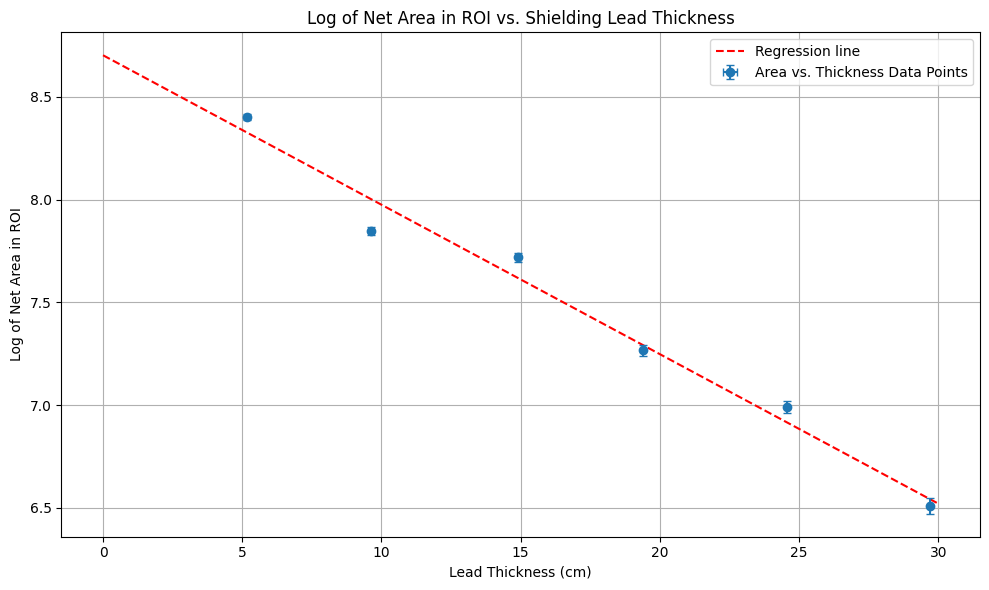

In [242]:
plt.figure(figsize=(10, 6))
plt.xlabel("Lead Thickness (cm)")
plt.ylabel("Log of Net Area in ROI")
plt.title("Log of Net Area in ROI vs. Shielding Lead Thickness")
plt.grid(True)

x_linspace = np.linspace(0, 30)
A_linspace = slope_p4 * x_linspace + intercept_p4
plt.plot(
    x_linspace,
    A_linspace,
    color="red",
    linestyle="--",
    label="Regression line",
)
plt.errorbar(
    dfp4["x"],
    dfp4["lnA"],
    xerr=dfp4["x_unc"],
    yerr=dfp4["lnA_unc"],
    fmt="o",
    capsize=3,
    label="Area vs. Thickness Data Points",
)
plt.legend()
plt.tight_layout()
plt.show()

In [243]:
print(slope_p4)
print(intercept_p4)
print(slope_std_err_p4)
print(intercept_std_err_p4)

-0.0727015488593651
8.70231989095447
0.004774243977844703
0.11144923418905714
